# 1. Data Understanding and Preprocessing

In this section, the raw real-time generation dataset is loaded and inspected. 
The timestamp column is constructed from date and hour information, missing values 
and duplicate timestamps are checked, and constant zero columns are removed. 
Exploratory analysis is then performed to identify temporal patterns and motivate 
the feature engineering stage.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Gercek_Zamanli_Uretim-01062025-01092025(in).csv"

df = pd.read_csv(
    DATA_PATH,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)
df.head()

,Tarih,Saat,Toplam,Doğal Gaz,Barajlı,Linyit,Akarsu,İthal Kömür,Rüzgar,Güneş,Fuel Oil,Jeotermal,Asfaltit Kömür,Taş Kömür,Biyokütle,Nafta,LNG,Uluslararası,Atık Isı
0,1.06.2025,00:00,33683.29,3973.20,5546.51,5344.77,3066.13,7449.12,5767.55,0.02,82.61,1282.08,79.48,461.44,939.94,0,0,-388.31,78.75
1,1.06.2025,01:00,31922.96,3919.76,4440.05,5334.59,2962.07,7223.17,5450.66,0.02,81.95,1295.04,81.69,471.33,933.66,0,0,-349.02,77.99
2,1.06.2025,02:00,30264.93,3392.73,4162.75,5323.11,2799.71,6676.81,5295.44,0.02,82.65,1302.76,81.69,470.14,941.09,0,0,-342.50,78.53
3,1.06.2025,03:00,29634.59,2120.49,4727.01,5287.57,2891.98,6571.34,5422.08,0.05,81.70,1305.33,79.48,465.67,934.30,0,0,-325.61,73.20
4,1.06.2025,04:00,29130.76,1711.66,4193.63,5256.06,2899.93,6965.39,5503.18,2.68,76.91,1309.43,81.69,462.30,943.73,0,0,-348.57,72.74


In [50]:
df["datetime"] = pd.to_datetime(
    df["Tarih"] + " " + df["Saat"],
    format="%d.%m.%Y %H:%M",
    errors="coerce"
)

df = df.sort_values("datetime").reset_index(drop=True)

df[["Tarih", "Saat", "datetime"]].head()

,Tarih,Saat,datetime
0,1.06.2025,00:00,2025-06-01 00:00:00
1,1.06.2025,01:00,2025-06-01 01:00:00
2,1.06.2025,02:00,2025-06-01 02:00:00
3,1.06.2025,03:00,2025-06-01 03:00:00
4,1.06.2025,04:00,2025-06-01 04:00:00


In [51]:
print("Shape:", df.shape)
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())

df.info()

Shape: (2232, 20)
Start: 2025-06-01 00:00:00
End: 2025-09-01 23:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2232 entries, 0 to 2231
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Tarih           2232 non-null   object        
 1   Saat            2232 non-null   object        
 2   Toplam          2232 non-null   float64       
 3   Doğal Gaz       2232 non-null   float64       
 4   Barajlı         2232 non-null   float64       
 5   Linyit          2232 non-null   float64       
 6   Akarsu          2232 non-null   float64       
 7   İthal Kömür     2232 non-null   float64       
 8   Rüzgar          2232 non-null   float64       
 9   Güneş           2232 non-null   float64       
 10  Fuel Oil        2232 non-null   float64       
 11  Jeotermal       2232 non-null   float64       
 12  Asfaltit Kömür  2232 non-null   float64       
 13  Taş Kömür       2232 non-null   float6

In [52]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols

['Toplam',
 'Doğal Gaz',
 'Barajlı',
 'Linyit',
 'Akarsu',
 'İthal Kömür',
 'Rüzgar',
 'Güneş',
 'Fuel Oil',
 'Jeotermal',
 'Asfaltit Kömür',
 'Taş Kömür',
 'Biyokütle',
 'Nafta',
 'LNG',
 'Uluslararası',
 'Atık Isı']

In [53]:
duplicate_datetimes = df["datetime"].duplicated().sum()
print("Duplicate timestamps:", duplicate_datetimes)

Duplicate timestamps: 0


In [54]:
time_diffs = df["datetime"].diff().dropna()

print(time_diffs.value_counts())
print("Non-hourly gaps:", (time_diffs != pd.Timedelta(hours=1)).sum())

datetime
0 days 01:00:00    2231
Name: count, dtype: int64
Non-hourly gaps: 0


In [55]:
constant_cols = []

for col in numeric_cols:
    if df[col].nunique() == 1:
        constant_cols.append(col)

constant_cols

['Nafta', 'LNG']

In [56]:
df = df.drop(columns=["Nafta", "LNG"])

In [57]:
source_cols = [
    col for col in df.select_dtypes(include="number").columns
    if col != "Toplam"
]

sum_sources = df[source_cols].sum(axis=1)

error = df["Toplam"] - sum_sources

print("Mean absolute error:", error.abs().mean())
print("Max absolute error:", error.abs().max())

Mean absolute error: 4.4912413095614765e-12
Max absolute error: 2.1827872842550278e-11


In [58]:
summary = df.select_dtypes(include="number").agg(
    ["min", "max", "mean", "std"]
).T

summary

,min,max,mean,std
Toplam,11175.31,56219.06,39387.652903,7871.805956
Doğal Gaz,583.34,17028.01,9539.469565,4644.162785
Barajlı,1076.33,16722.49,5292.658392,3181.982984
Linyit,1775.49,6019.76,4498.630009,682.712463
Akarsu,451.69,4015.34,1469.348159,637.987730
İthal Kömür,3572.15,10172.67,9331.651254,1476.476946
Rüzgar,323.46,10612.45,5360.477935,2388.272920
Güneş,0.00,3394.37,1254.703535,1320.093339
Fuel Oil,44.21,109.22,86.112885,11.103434
Jeotermal,799.20,1314.83,1043.062307,96.718299


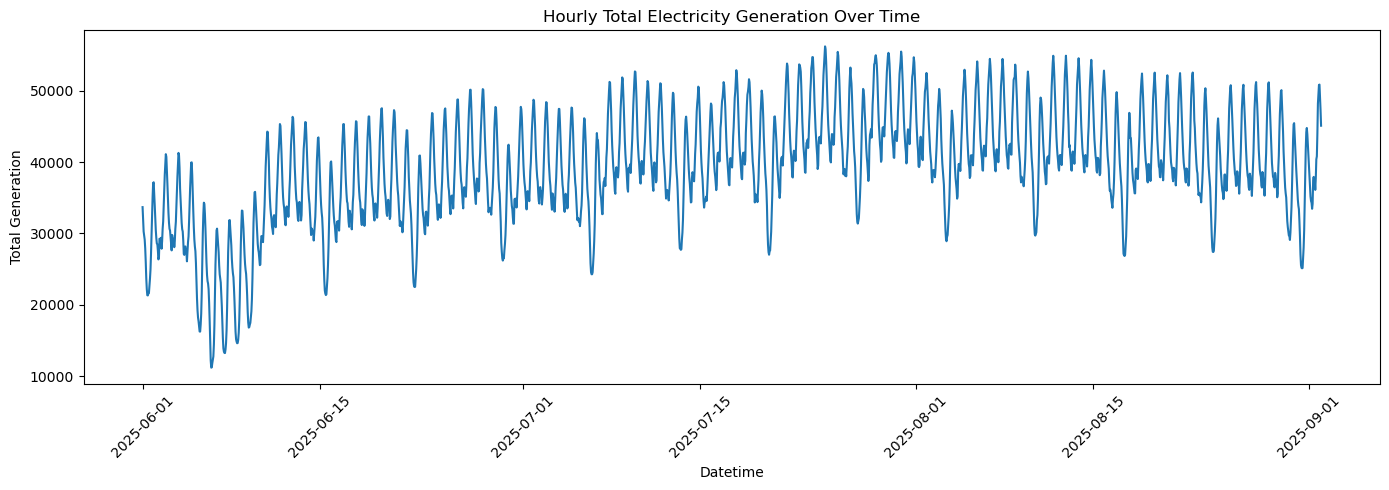

In [59]:
plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["Toplam"])
plt.xlabel("Datetime")
plt.ylabel("Total Generation")
plt.title("Hourly Total Electricity Generation Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

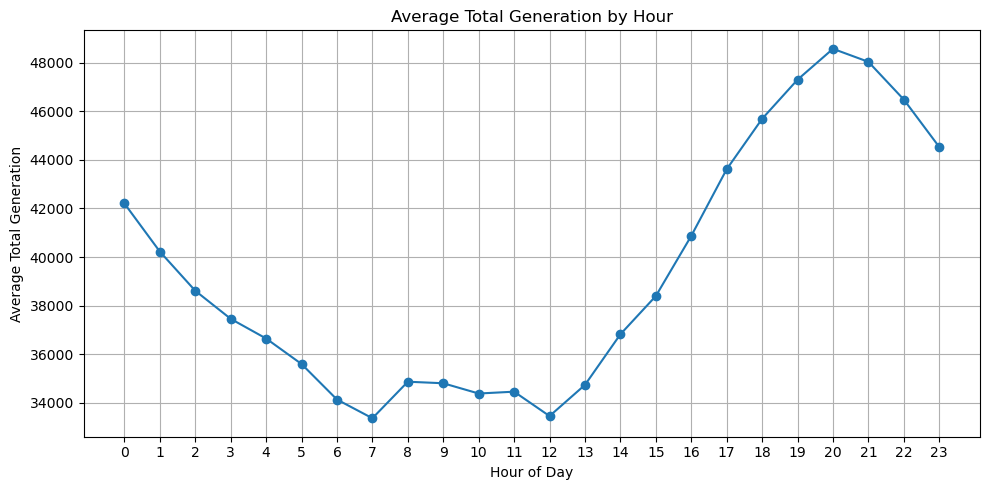

In [60]:
df["hour"] = df["datetime"].dt.hour

hourly_avg = df.groupby("hour")["Toplam"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Generation")
plt.title("Average Total Generation by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

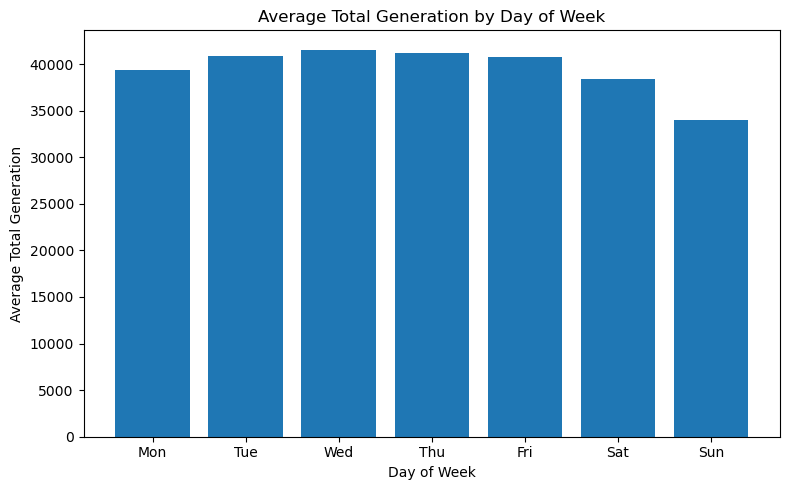

In [61]:
df["dayofweek"] = df["datetime"].dt.dayofweek

dow_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

dow_avg = df.groupby("dayofweek")["Toplam"].mean()

plt.figure(figsize=(8, 5))
plt.bar([dow_map[i] for i in dow_avg.index], dow_avg.values)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Generation")
plt.title("Average Total Generation by Day of Week")
plt.tight_layout()
plt.show()

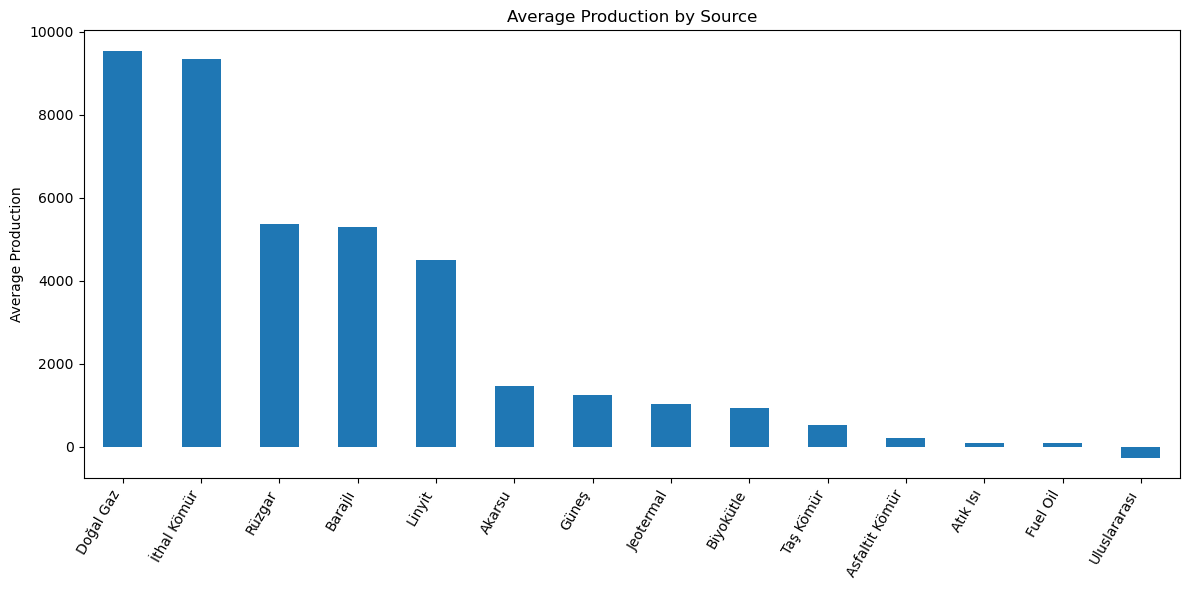

In [62]:
source_cols = [
    col for col in df.select_dtypes(include="number").columns
    if col not in ["Toplam", "hour", "dayofweek"]
]

source_means = df[source_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
source_means.plot(kind="bar")
plt.ylabel("Average Production")
plt.title("Average Production by Source")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

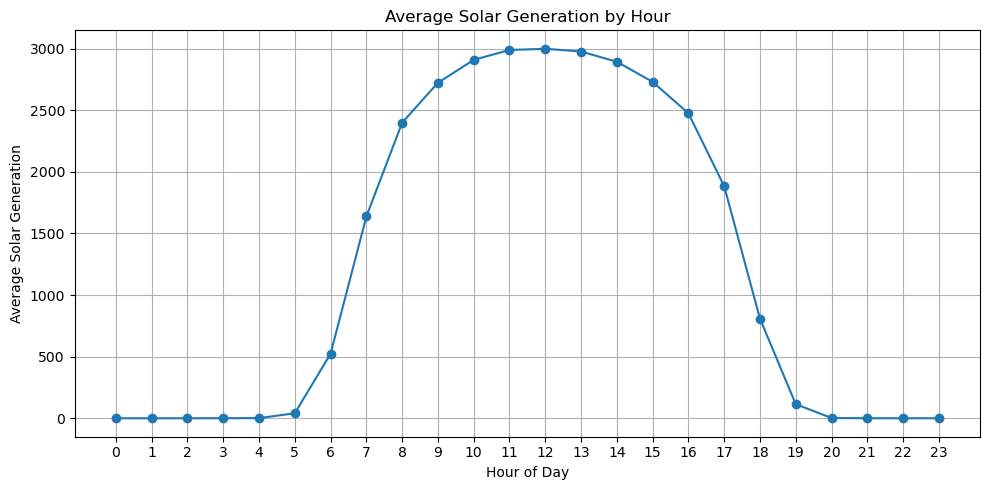

In [63]:
solar_hourly = df.groupby("hour")["Güneş"].mean()

plt.figure(figsize=(10, 5))
plt.plot(solar_hourly.index, solar_hourly.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Solar Generation")
plt.title("Average Solar Generation by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

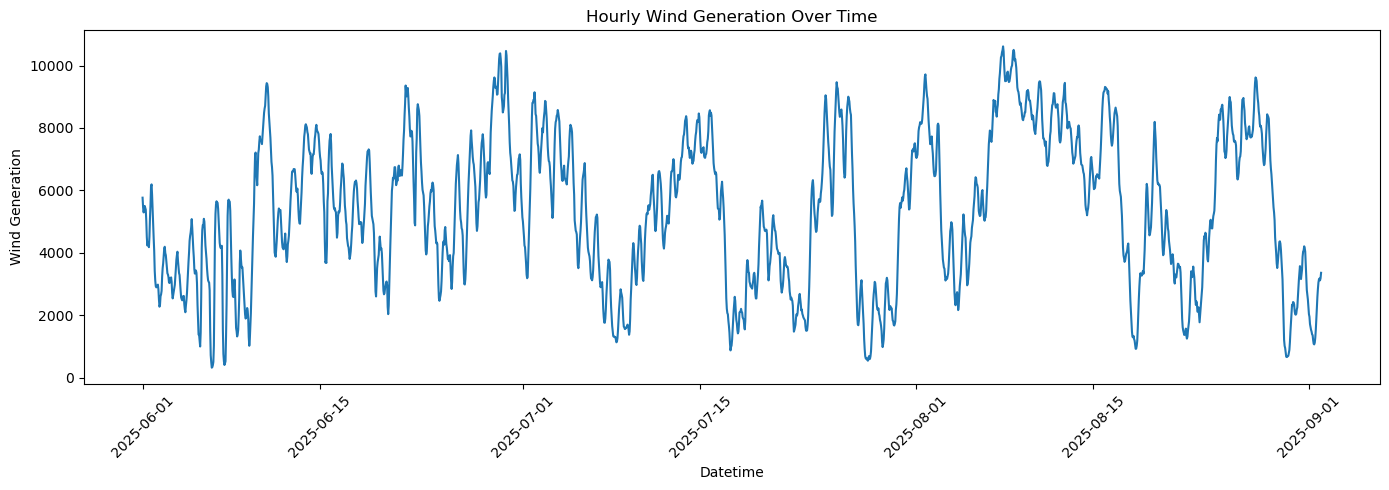

In [64]:
plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["Rüzgar"])
plt.xlabel("Datetime")
plt.ylabel("Wind Generation")
plt.title("Hourly Wind Generation Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

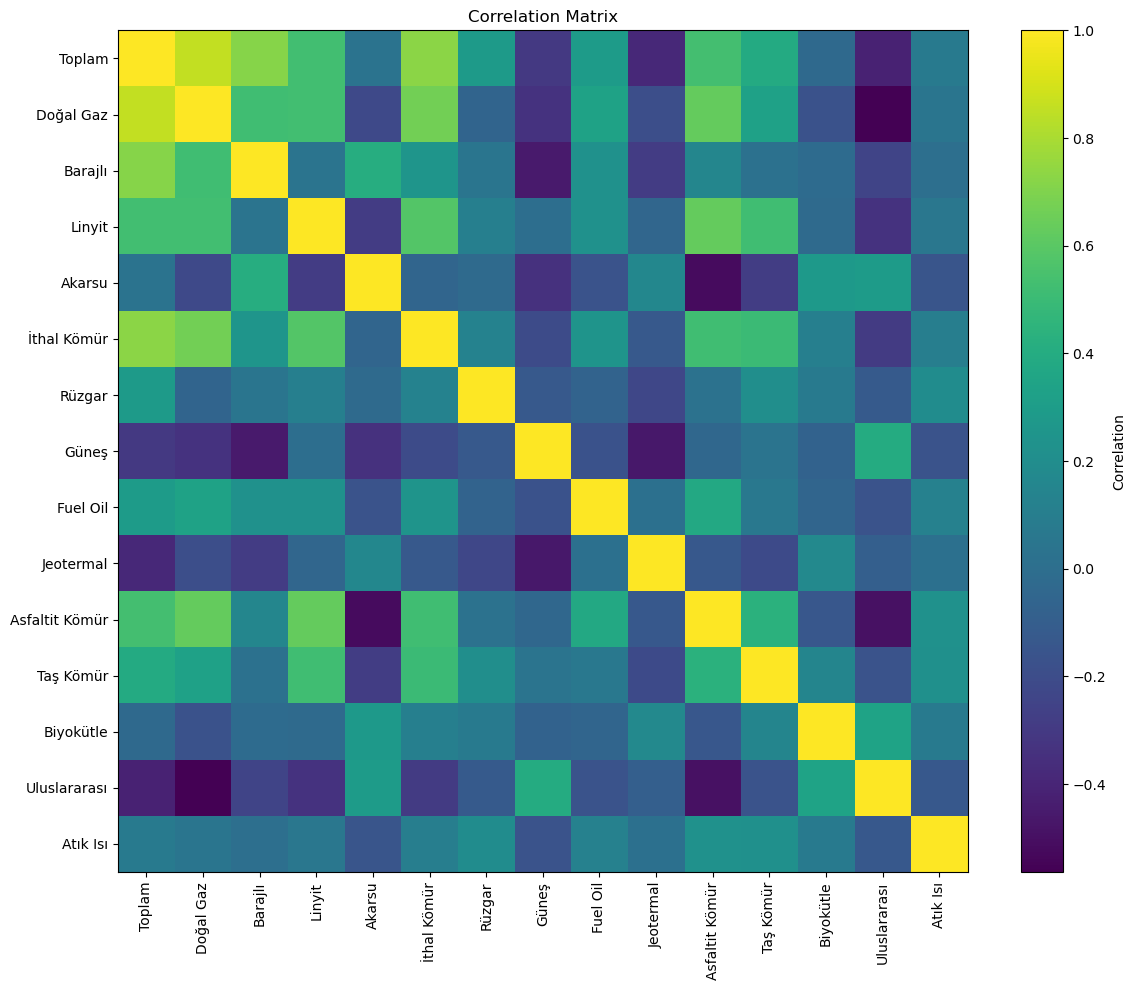

In [65]:
corr_cols = ["Toplam"] + source_cols

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [66]:
lags = [1, 2, 3, 24, 48, 168]

for lag in lags:
    print(f"Lag {lag}: {df['Toplam'].autocorr(lag=lag):.3f}")

Lag 1: 0.977
Lag 2: 0.919
Lag 3: 0.836
Lag 24: 0.878
Lag 48: 0.786
Lag 168: 0.874


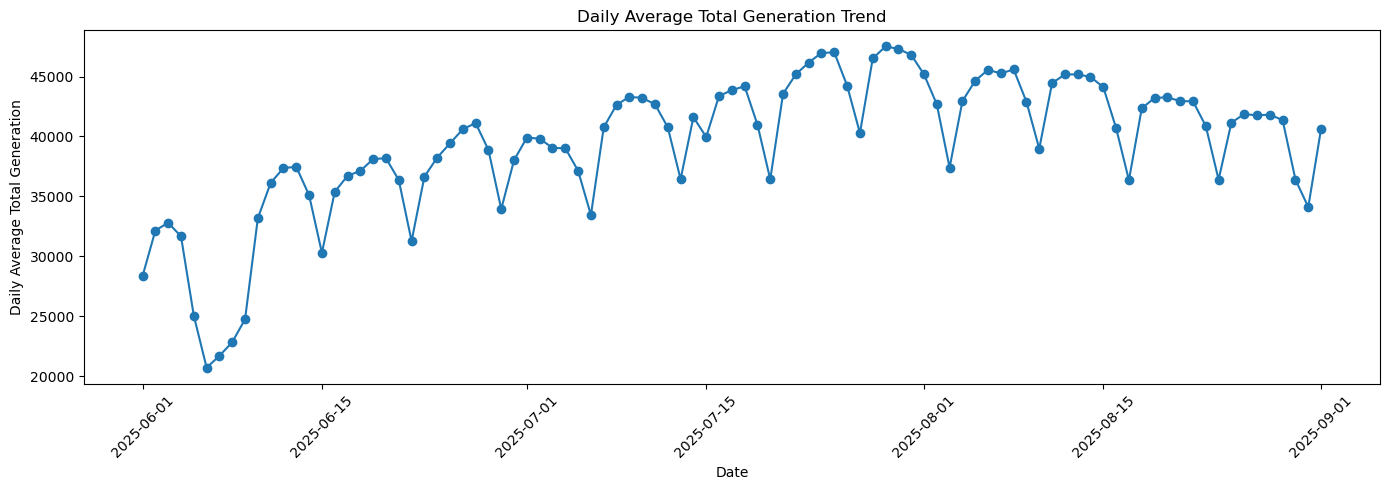

In [67]:
df["date"] = df["datetime"].dt.date

daily_avg = df.groupby("date")["Toplam"].mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_avg.index, daily_avg.values, marker="o")
plt.xlabel("Date")
plt.ylabel("Daily Average Total Generation")
plt.title("Daily Average Total Generation Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

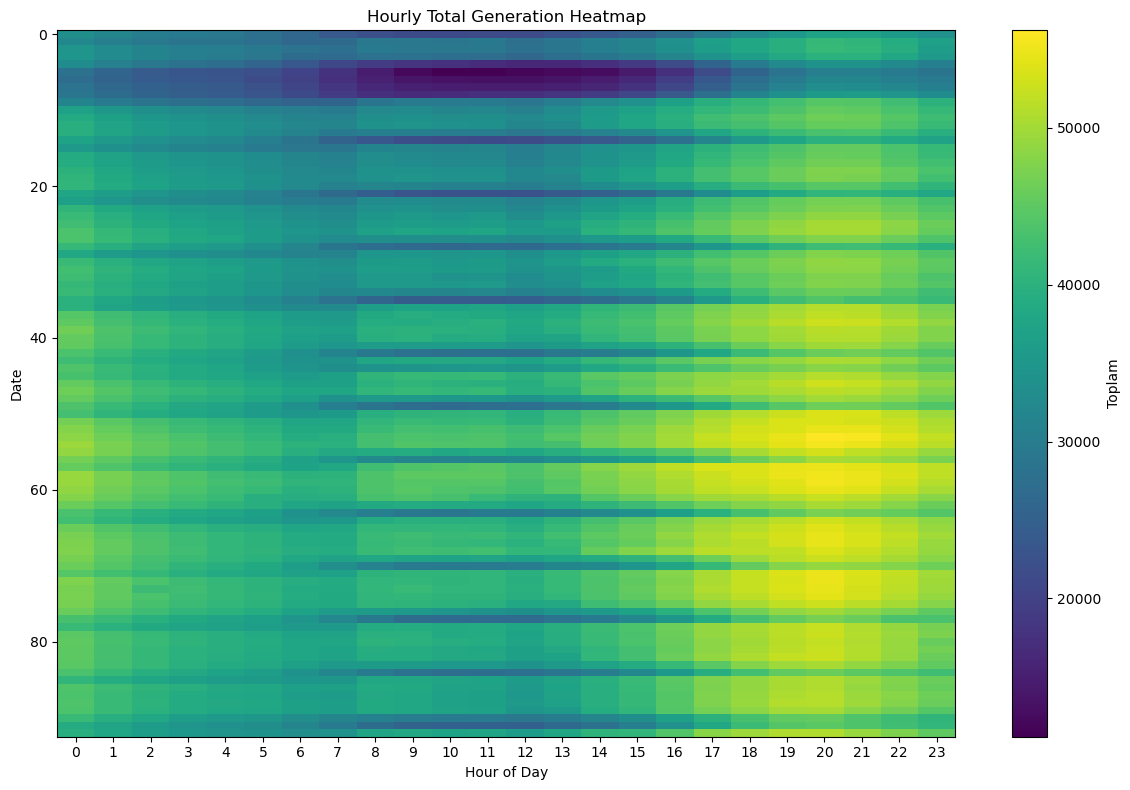

In [68]:
pivot = df.pivot_table(
    index=df["datetime"].dt.date,
    columns=df["datetime"].dt.hour,
    values="Toplam",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Toplam")
plt.xlabel("Hour of Day")
plt.ylabel("Date")
plt.title("Hourly Total Generation Heatmap")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# 2. Feature Engineering

In this section, new predictive features are created from the timestamp and previous generation values. 
The target variable is total electricity generation at prediction time t. To avoid target leakage, 
same-time source production columns are not used as features. Instead, lagged and rolling historical 
values are used.

In [69]:
# Make a copy so feature engineering does not damage the cleaned EDA dataframe
df_fe = df.copy()

# Target: total generation at prediction time t
df_fe["target"] = df_fe["Toplam"]

## Lag features for total generation

In [70]:
# Basic time features
df_fe["hour"] = df_fe["datetime"].dt.hour
df_fe["dayofweek"] = df_fe["datetime"].dt.dayofweek
df_fe["day"] = df_fe["datetime"].dt.day
df_fe["month"] = df_fe["datetime"].dt.month
df_fe["is_weekend"] = df_fe["dayofweek"].isin([5, 6]).astype(int)

In [71]:
# Cyclic hour encoding
df_fe["hour_sin"] = np.sin(2 * np.pi * df_fe["hour"] / 24)
df_fe["hour_cos"] = np.cos(2 * np.pi * df_fe["hour"] / 24)

# Cyclic day-of-week encoding
df_fe["dow_sin"] = np.sin(2 * np.pi * df_fe["dayofweek"] / 7)
df_fe["dow_cos"] = np.cos(2 * np.pi * df_fe["dayofweek"] / 7)

In [72]:
calendar_features = [
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

In [73]:
toplam_lags = [1, 2, 3, 24, 48, 168]

for lag in toplam_lags:
    df_fe[f"Toplam_lag_{lag}"] = df_fe["Toplam"].shift(lag)

toplam_lag_features = [f"Toplam_lag_{lag}" for lag in toplam_lags]

In [74]:
# Current-time source columns after removing Nafta and LNG
source_cols = [
    "Doğal Gaz",
    "Barajlı",
    "Linyit",
    "Akarsu",
    "İthal Kömür",
    "Rüzgar",
    "Güneş",
    "Fuel Oil",
    "Jeotermal",
    "Asfaltit Kömür",
    "Taş Kömür",
    "Biyokütle",
    "Uluslararası",
    "Atık Isı"
]

In [75]:
source_lag_features = []

for col in source_cols:
    feature_name = f"{col}_lag_1"
    df_fe[feature_name] = df_fe[col].shift(1)
    source_lag_features.append(feature_name)

In [76]:
rolling_windows = [3, 6, 24]

rolling_features = []

for window in rolling_windows:
    mean_name = f"Toplam_roll_{window}_mean"
    std_name = f"Toplam_roll_{window}_std"
    
    df_fe[mean_name] = df_fe["Toplam"].shift(1).rolling(window).mean()
    df_fe[std_name] = df_fe["Toplam"].shift(1).rolling(window).std()
    
    rolling_features.extend([mean_name, std_name])

In [77]:
df_fe["Toplam_diff_1"] = df_fe["Toplam_lag_1"] - df_fe["Toplam_lag_2"]
df_fe["Toplam_diff_24"] = df_fe["Toplam_lag_1"] - df_fe["Toplam_lag_24"]

trend_features = [
    "Toplam_diff_1",
    "Toplam_diff_24"
]

In [78]:
baseline_features = calendar_features

In [79]:
main_features = (
    calendar_features
    + toplam_lag_features
    + source_lag_features
    + rolling_features
    + trend_features
)

In [80]:
required_cols = ["target"] + main_features

df_model = df_fe.dropna(subset=required_cols).copy()

print("Original rows:", len(df_fe))
print("Rows after feature engineering:", len(df_model))
print("Rows removed:", len(df_fe) - len(df_model))

Original rows: 2232
Rows after feature engineering: 2064
Rows removed: 168


In [81]:
X_calendar = df_model[baseline_features].copy()
X_main = df_model[main_features].copy()
y = df_model["target"].copy()

print("Calendar-only feature count:", X_calendar.shape[1])
print("Main feature count:", X_main.shape[1])
print("Number of samples:", X_main.shape[0])

Calendar-only feature count: 9
Main feature count: 37
Number of samples: 2064


In [82]:
forbidden_cols = ["Toplam"] + source_cols

leaked_cols = [col for col in forbidden_cols if col in X_main.columns]

print("Leakage columns found:", leaked_cols)

Leakage columns found: []


In [83]:
assert "target" not in X_main.columns
assert "Toplam" not in X_main.columns

In [88]:
X_main.head()

,hour,dayofweek,day,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,Toplam_lag_1,...,Uluslararası_lag_1,Atık Isı_lag_1,Toplam_roll_3_mean,Toplam_roll_3_std,Toplam_roll_6_mean,Toplam_roll_6_std,Toplam_roll_24_mean,Toplam_roll_24_std,Toplam_diff_1,Toplam_diff_24
168,0,6,8,6,1,0.000000,1.000000,-0.781831,0.62349,29532.59,...,113.54,94.43,30694.660000,1168.126383,30178.631667,1680.265654,21698.105833,6559.158494,-1150.05,2171.39
169,1,6,8,6,1,0.258819,0.965926,-0.781831,0.62349,28306.93,...,89.82,91.69,29507.386667,1188.055515,30330.051667,1396.605160,21737.511250,6597.389266,-1225.66,2790.62
170,2,6,8,6,1,0.500000,0.866025,-0.781831,0.62349,26402.44,...,94.86,93.77,28080.653333,1577.295344,29768.785000,2143.591779,21774.433333,6621.890773,-1904.49,2139.86
171,3,6,8,6,1,0.707107,0.707107,-0.781831,0.62349,25223.89,...,78.38,94.80,26644.420000,1555.699087,28669.540000,2536.773694,21814.487917,6640.476780,-1178.55,1586.60
172,4,6,8,6,1,0.866025,0.500000,-0.781831,0.62349,24408.60,...,111.96,95.50,25344.976667,1002.420058,27426.181667,2482.785906,21846.625833,6651.539392,-815.29,1304.34


In [89]:
y.head()

168    28306.93
169    26402.44
170    25223.89
171    24408.60
172    23857.49
Name: target, dtype: float64

In [85]:
preview_cols = ["datetime", "target"] + main_features[:10]

df_model[preview_cols].head()

,datetime,target,hour,dayofweek,day,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,Toplam_lag_1
168,2025-06-08 00:00:00,28306.93,0,6,8,6,1,0.000000,1.000000,-0.781831,0.62349,29532.59
169,2025-06-08 01:00:00,26402.44,1,6,8,6,1,0.258819,0.965926,-0.781831,0.62349,28306.93
170,2025-06-08 02:00:00,25223.89,2,6,8,6,1,0.500000,0.866025,-0.781831,0.62349,26402.44
171,2025-06-08 03:00:00,24408.60,3,6,8,6,1,0.707107,0.707107,-0.781831,0.62349,25223.89
172,2025-06-08 04:00:00,23857.49,4,6,8,6,1,0.866025,0.500000,-0.781831,0.62349,24408.60


In [86]:
print("Baseline features:")
for feature in baseline_features:
    print("-", feature)

print("\nMain features:")
for feature in main_features:
    print("-", feature)

Baseline features:
- hour
- dayofweek
- day
- month
- is_weekend
- hour_sin
- hour_cos
- dow_sin
- dow_cos

Main features:
- hour
- dayofweek
- day
- month
- is_weekend
- hour_sin
- hour_cos
- dow_sin
- dow_cos
- Toplam_lag_1
- Toplam_lag_2
- Toplam_lag_3
- Toplam_lag_24
- Toplam_lag_48
- Toplam_lag_168
- Doğal Gaz_lag_1
- Barajlı_lag_1
- Linyit_lag_1
- Akarsu_lag_1
- İthal Kömür_lag_1
- Rüzgar_lag_1
- Güneş_lag_1
- Fuel Oil_lag_1
- Jeotermal_lag_1
- Asfaltit Kömür_lag_1
- Taş Kömür_lag_1
- Biyokütle_lag_1
- Uluslararası_lag_1
- Atık Isı_lag_1
- Toplam_roll_3_mean
- Toplam_roll_3_std
- Toplam_roll_6_mean
- Toplam_roll_6_std
- Toplam_roll_24_mean
- Toplam_roll_24_std
- Toplam_diff_1
- Toplam_diff_24


In [87]:
feature_corr = X_main.copy()
feature_corr["target"] = y

corr_with_target = (
    feature_corr.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

corr_with_target.head(15)

Toplam_lag_1           0.971615
Toplam_roll_3_mean     0.906738
Toplam_lag_2           0.901064
Toplam_lag_168         0.873593
Toplam_lag_24          0.858930
Toplam_lag_3           0.800132
Doğal Gaz_lag_1        0.784092
Toplam_lag_48          0.772915
Toplam_roll_6_mean     0.768407
Barajlı_lag_1          0.735036
Toplam_roll_24_mean    0.618999
İthal Kömür_lag_1      0.599777
hour_sin              -0.549426
Jeotermal_lag_1       -0.492167
hour                   0.457154
Name: target, dtype: float64